# 三角形

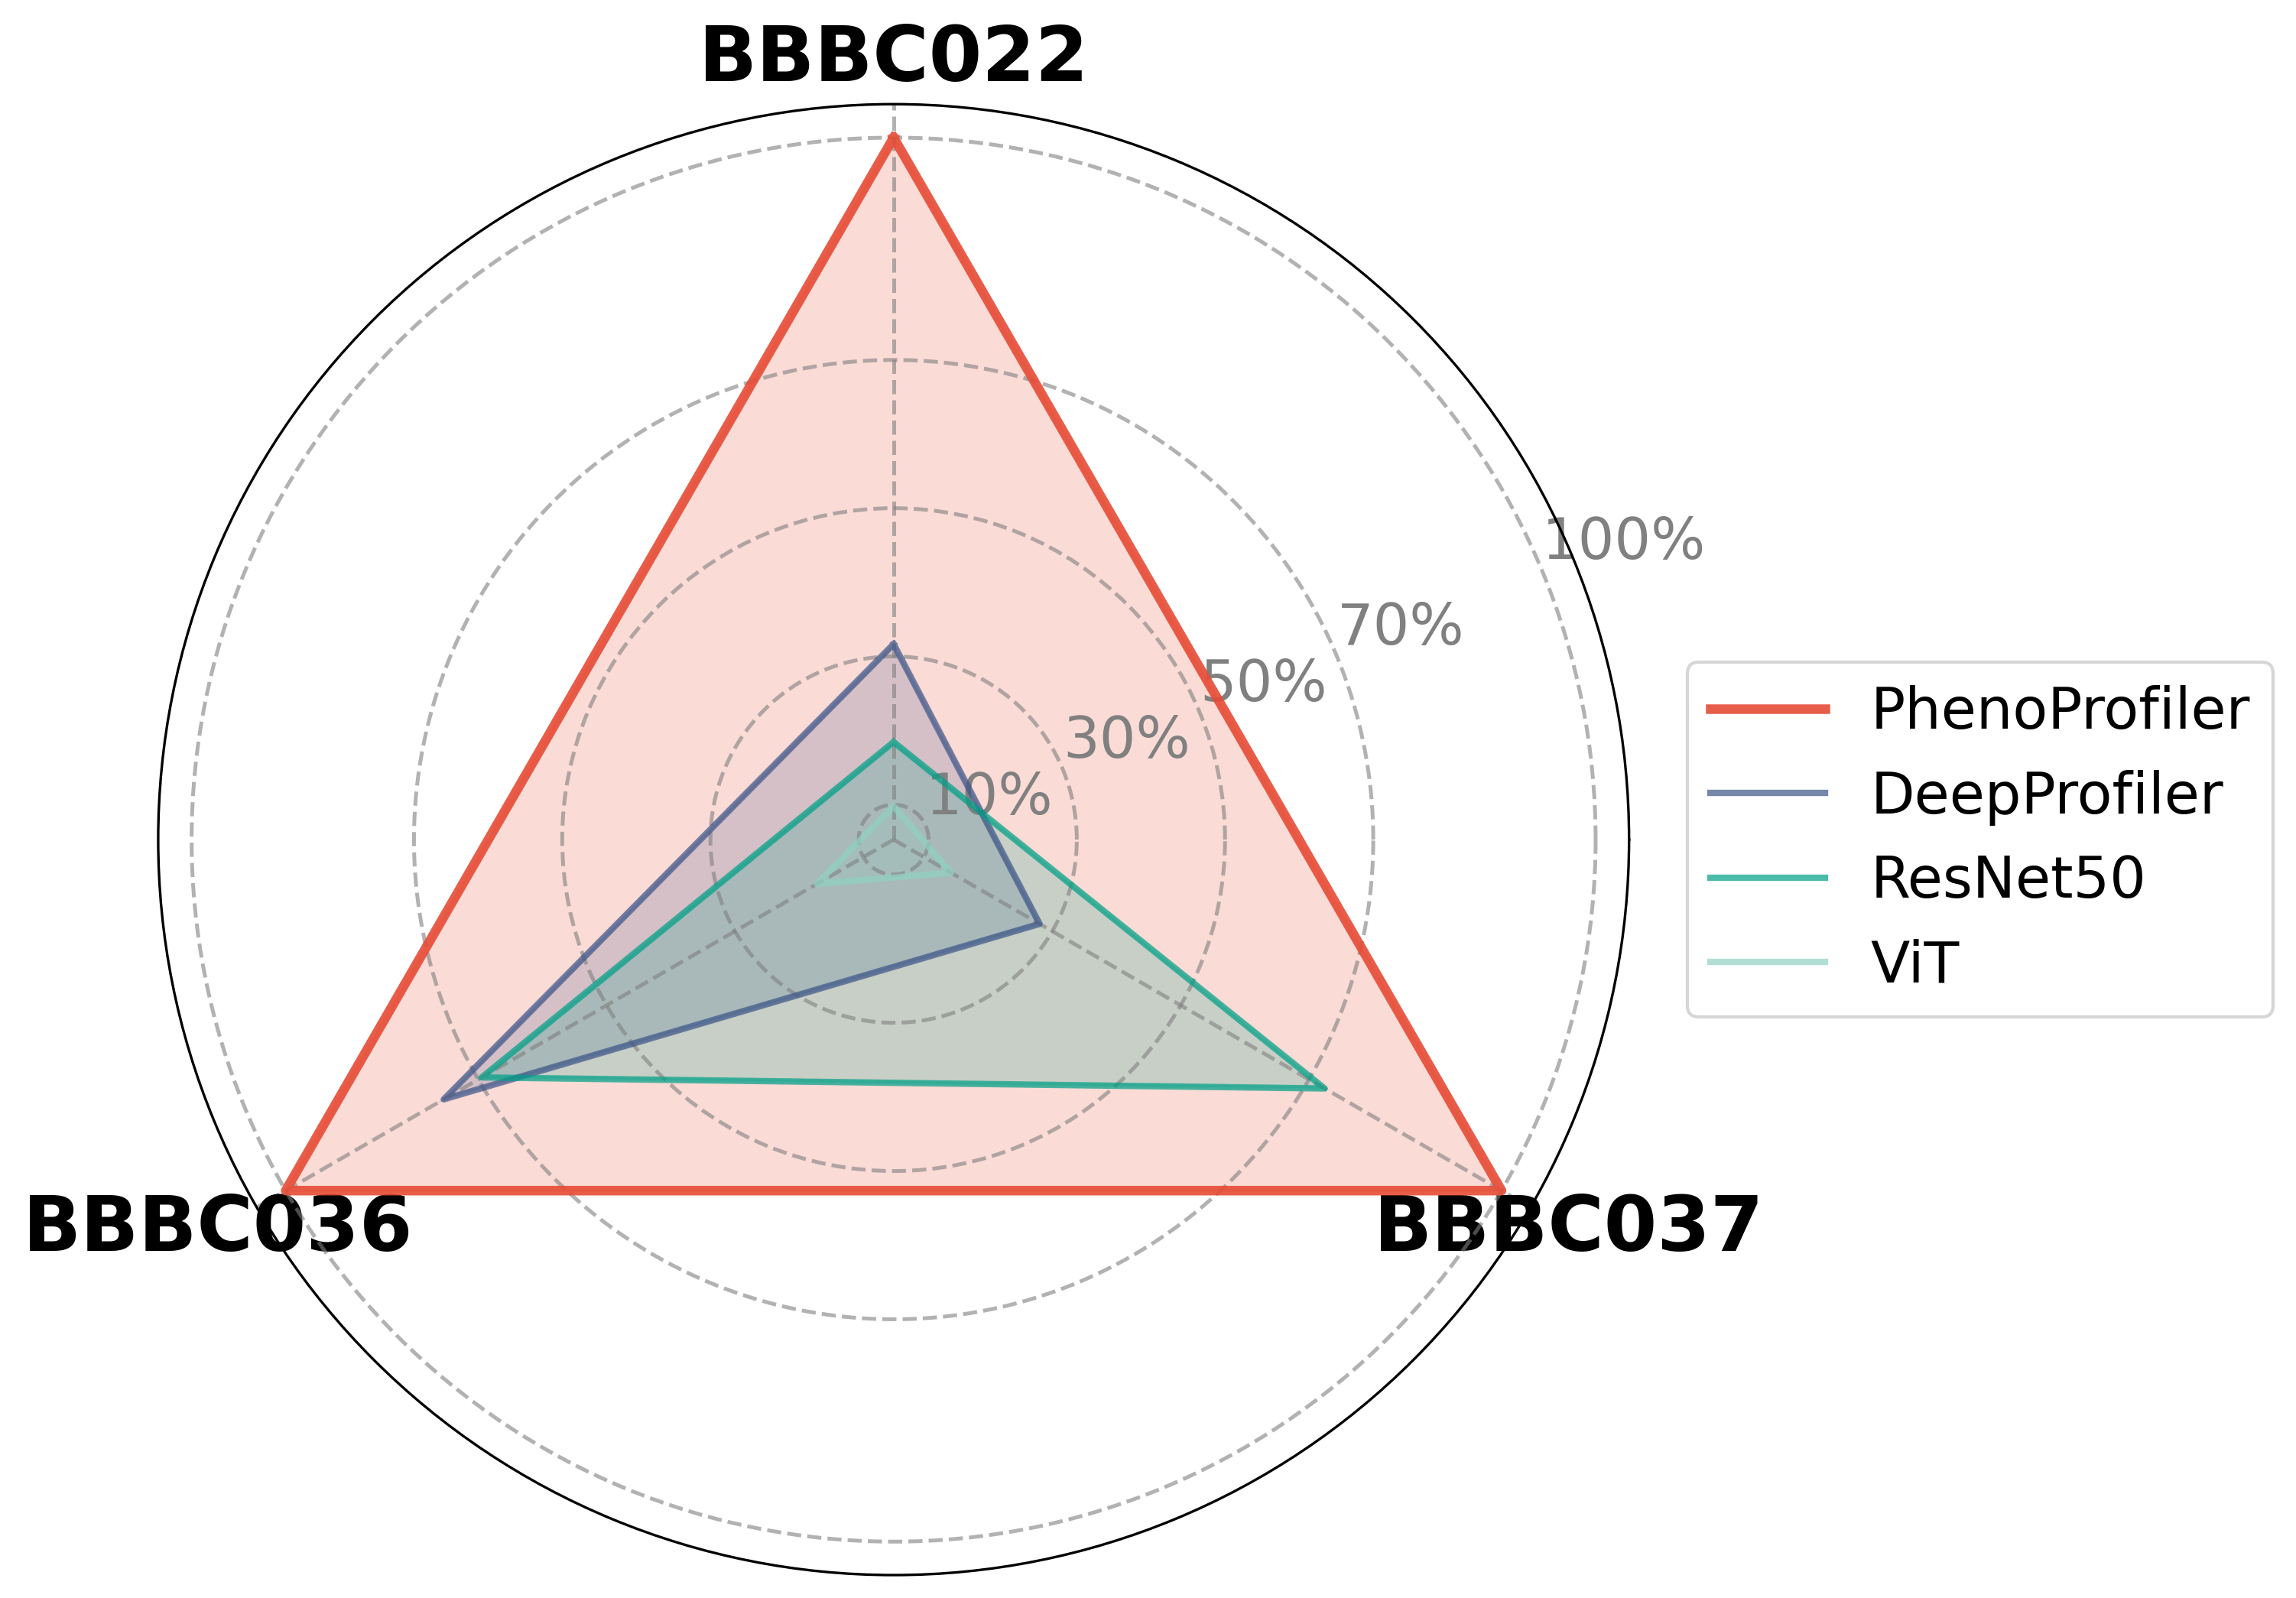

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 数据
methods = ['PhenoProfiler', 'DeepProfiler', 'ResNet50', 'ViT']
categories = ['BBBC022', 'BBBC036', 'BBBC037']
values = np.array([
    [41.3, 25.9, 14.9],
    [26.3, 23.4, 10.2],
    [23.4, 22.8, 13.1],
    [21.5, 17.5, 9.3]
])

# 找到每个类别的最大值
max_values = values.max(axis=0)

# 通过每个类别的最大值归一化数据
normalized_values = values / max_values

# 雷达图设置
num_vars = len(categories)

# 计算每个轴的角度
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# 确保一个顶点直接向上
rotation_offset = np.pi / 2  # 旋转90度使顶点向上
angles = [(angle + rotation_offset) % (2 * np.pi) for angle in np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()]
angles += angles[:1]  # 完成循环

# 找到每个类别的最小值并调整y轴范围
min_values = values.min(axis=0)
adjusted_min_values = min_values * 0.9  # 设置最小值稍低以便更好地可视化

# 基于调整后的最小值和最大值归一化数据
adjusted_values = (values - adjusted_min_values) / (max_values - adjusted_min_values)

# 使用不同的颜色调色板
nature_science_palette = ['#E64B35B2', '#3C5488B2', '#00A087B2', '#91D1C2B2']

# 使用Nature/Science风格的颜色调色板设置雷达图
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True), dpi=300)

# 设置图表背景颜色为更深的灰色并具有更明显的透明度
ax.set_facecolor((0.8, 0.8, 0.8, 0.4))  # 更深的灰色和更高的透明度

ax.set_facecolor('white')
# 自定义图表背景和网格线
ax.grid(color='grey', linestyle='--', linewidth=1.2, alpha=0.6)
# 隐藏背景圆圈和网格线
ax.grid(True)

ax.set_yticklabels([])
ax.set_yticks([])

# 使用Nature/Science风格的颜色绘制每种方法的雷达图
for i, method in enumerate(methods):
    data = adjusted_values[i].tolist()  
    data += data[:1]  # 完成循环
    if method == 'PhenoProfiler':
        ax.plot(angles, data, linewidth=3, linestyle='solid', color=nature_science_palette[i], label=method, alpha=0.9)
    else:
        ax.plot(angles, data, linewidth=2, linestyle='solid', color=nature_science_palette[i], label=method, alpha=0.7)
    ax.fill(angles, data, color=nature_science_palette[i], alpha=0.2)

# 调整y轴刻度以便更好地可视化
ax.set_yticks([0.1, 0.3, 0.5, 0.7, 1.0])
ax.set_yticklabels(['10%', '30%', '50%', '70%', '100%'], fontsize=18, color='grey')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=24, color='black', fontweight='bold')  # Set task labels to black and bold

# # # 添加更优雅的图例，字体更大，背景更轻
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=18, frameon=True, framealpha=0.8)

# # 移除默认标题以保持图表简洁
# plt.title("", fontsize=22)

# 显示图表
plt.tight_layout()
# plt.savefig('./3b_1.pdf', bbox_inches='tight', dpi=300)  # 或者 'output.pdf'
plt.show()


# 五边形

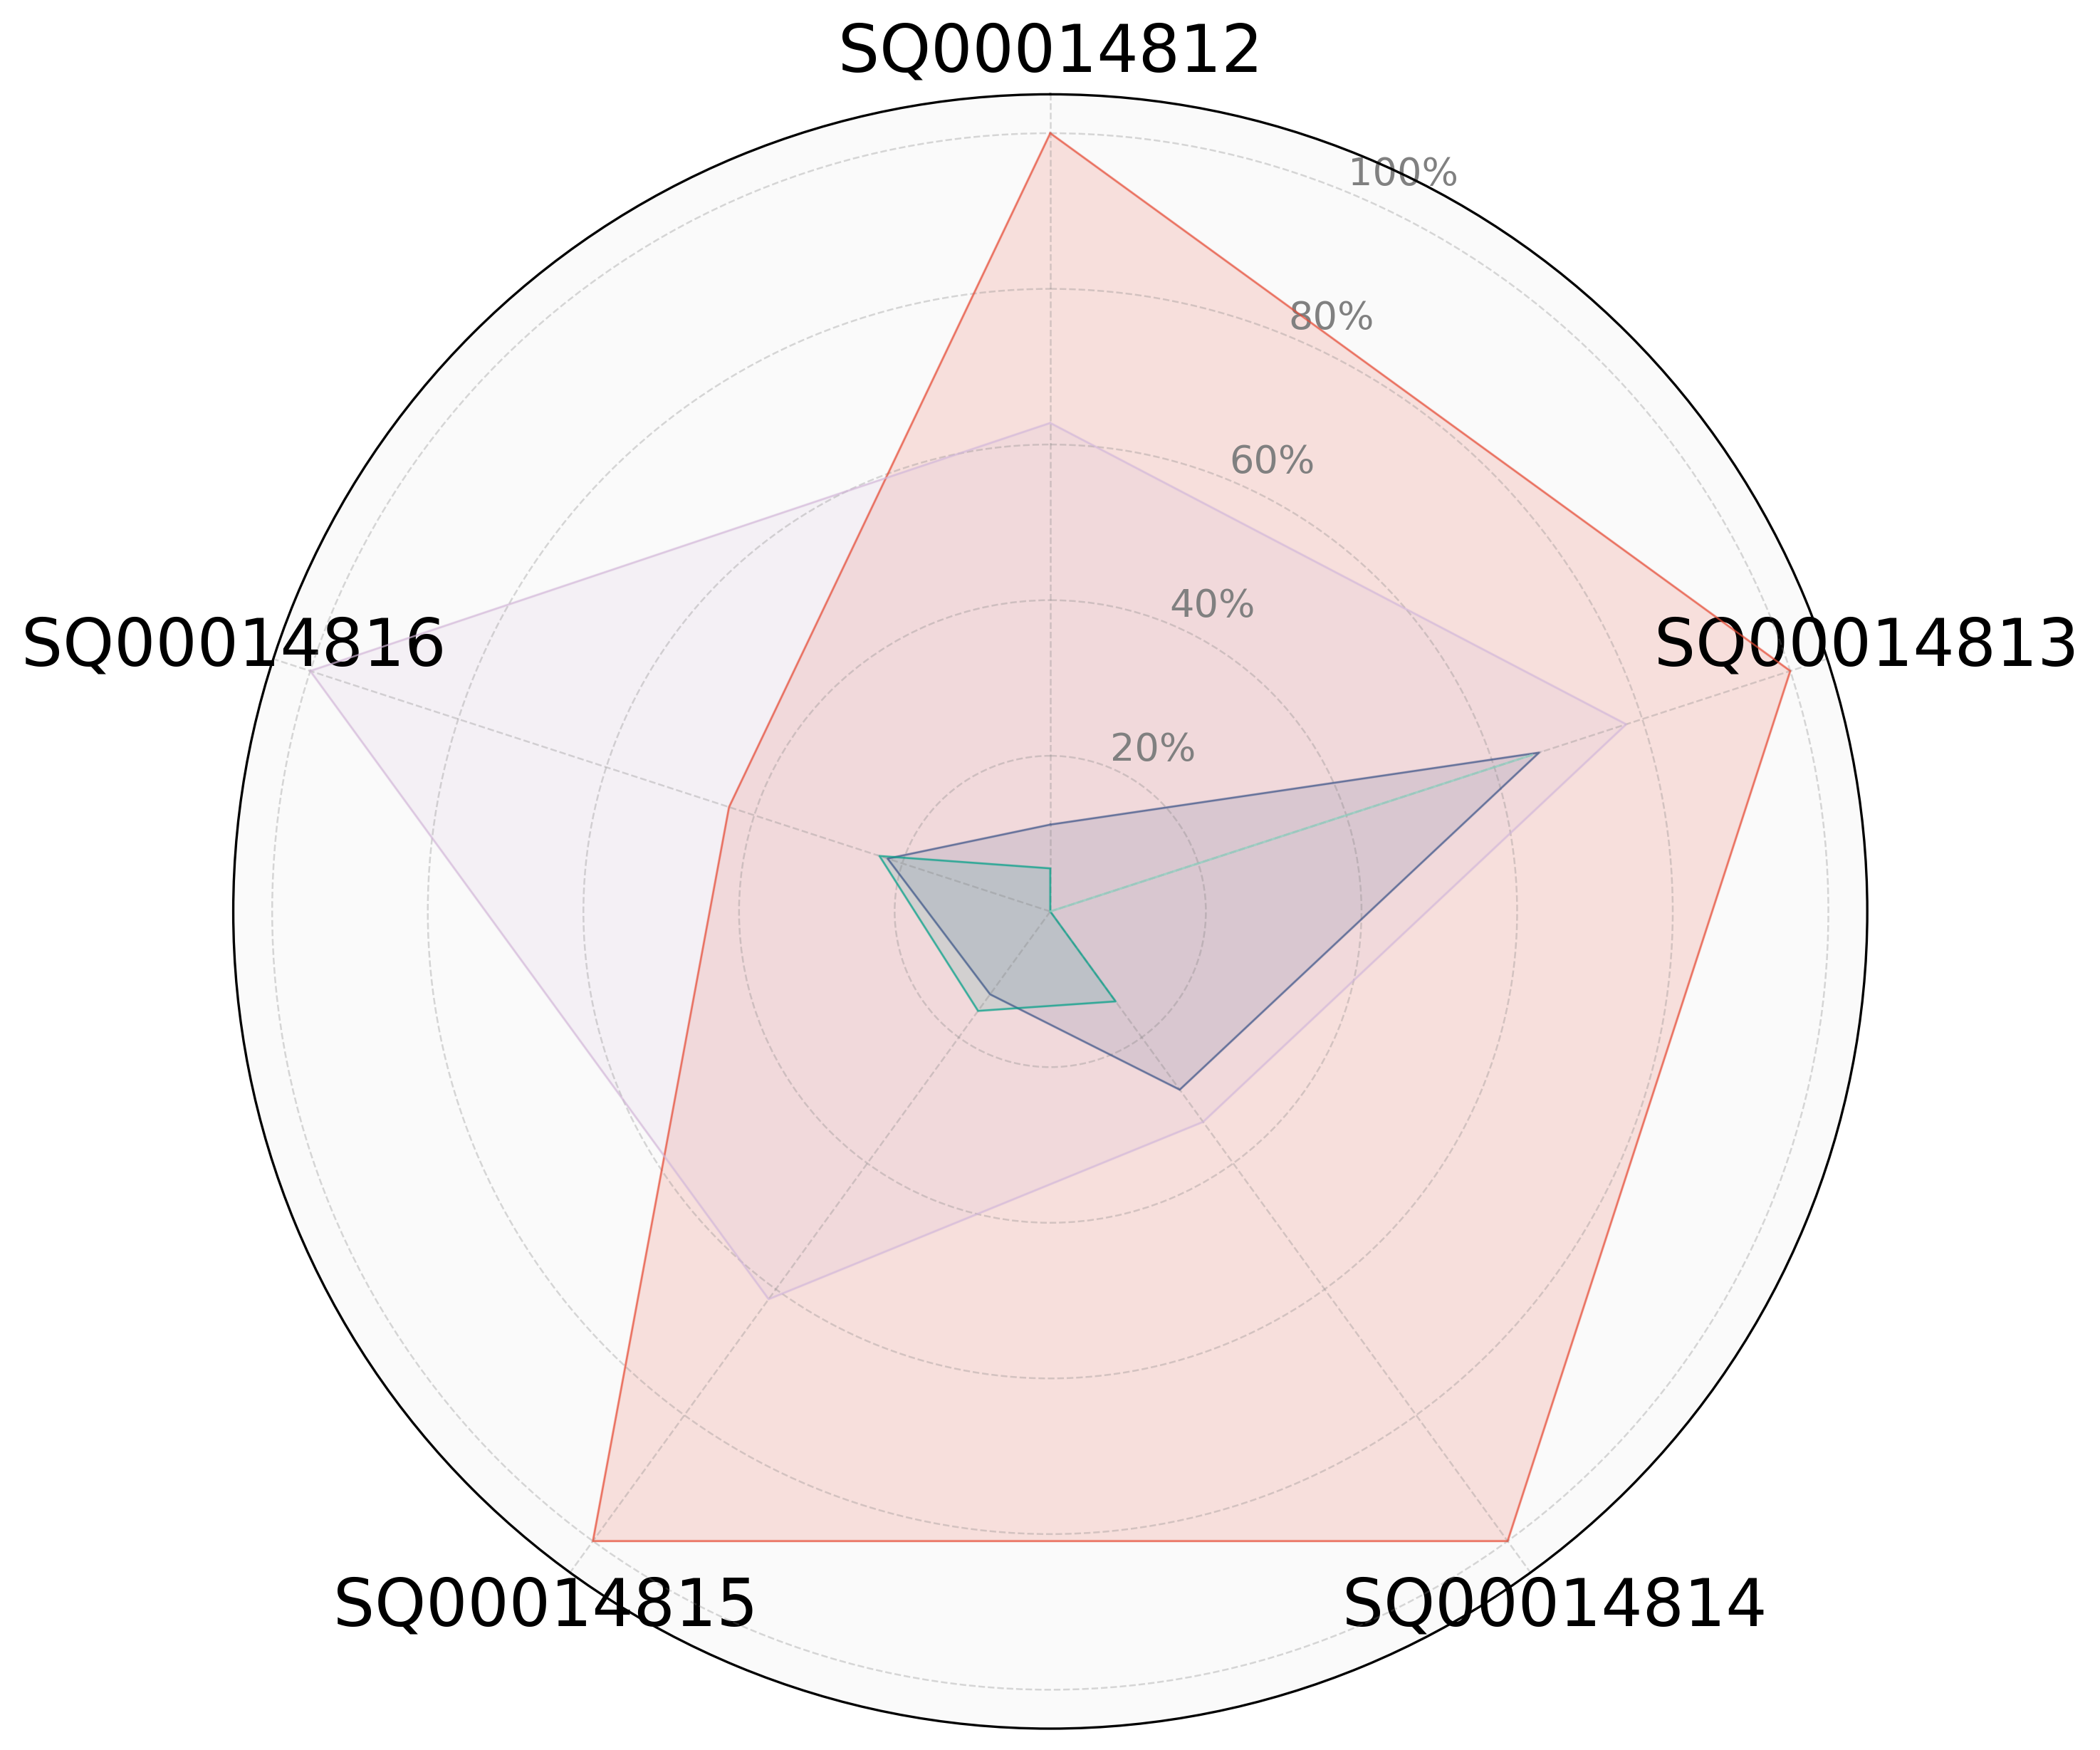

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# 全局字体设置（与3b代码一致）
plt.rcParams['font.size'] = 14  # 字体大小
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 14

# 方法名称
methods = ['PhenoProfiler', 'DeepProfiler', 'ResNet50', 'ViT', 'OpenPhenom']

# 数据集名称
datasets = [f"SQ000148{i+12}" for i in range(5)]

# 每种方法在每个数据集上的mAP值
performance = np.array([
    [0.1931, 0.141,  0.1784, 0.188,  0.1815],  # PhenoProfiler
    [0.0936, 0.0966, 0.1237, 0.089,   0.162],    # DeepProfiler
    [0.0873, 0.0102, 0.113,  0.092,   0.163],    # ResNet50
    [0.0811, 0.0954, 0.1021, 0.074,   0.142],    # ViT
    [0.1514, 0.112,  0.1276, 0.1442,  0.233]    # OpenPhenom
])

# 找到每个数据集的最大值和最小值
max_values = performance.max(axis=0)
min_values = performance.min(axis=0)

# 归一化数据
normalized_performance = (performance - min_values) / (max_values - min_values)

# 计算角度
angles = np.linspace(0, 2 * pi, len(datasets), endpoint=False).tolist()
angles += angles[:1]  # 闭合图形

# 使用与3b代码类似的高级配色方案
nature_science_palette = ['#E64B35B2', '#3C5488B2', '#00A087B2', '#91D1C2B2', '#D4B9DA']

# 雷达图设置
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True), dpi=300)

# 设置背景颜色和网格线
# ax.set_facecolor((0.8, 0.8, 0.8, 0.4))  # 深灰色背景
ax.set_facecolor((0.9, 0.9, 0.9, 0.2))  # 更浅的灰色，更低透明度
ax.grid(color='grey', linestyle='--', linewidth=0.6, alpha=0.3)

# 绘制雷达图
for i, method in enumerate(methods):
    values = normalized_performance[i].tolist()
    values += values[:1]  # 闭合图形
    ax.plot(angles, values, linewidth=0.6, linestyle='solid', color=nature_science_palette[i], label=method, alpha=0.7)
    ax.fill(angles, values, color=nature_science_palette[i], alpha=0.15)

# 设置角度和标签
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(datasets, fontsize=22, color='black')  # 数据集标签为黑色加粗

# 设置Y轴标签
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], fontsize=13, color='grey')

# 添加图例
# legend = ax.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1), fontsize=18, frameon=True, framealpha=0.8)
# for text in legend.get_texts():
#     text.set_color(nature_science_palette[methods.index(text.get_text())])  # 图例颜色与线条颜色一致

# 保存和显示图形
plt.tight_layout()
# plt.savefig('./3e_MAP.pdf', bbox_inches='tight', dpi=300)
plt.show()

# 雷达图-六边形

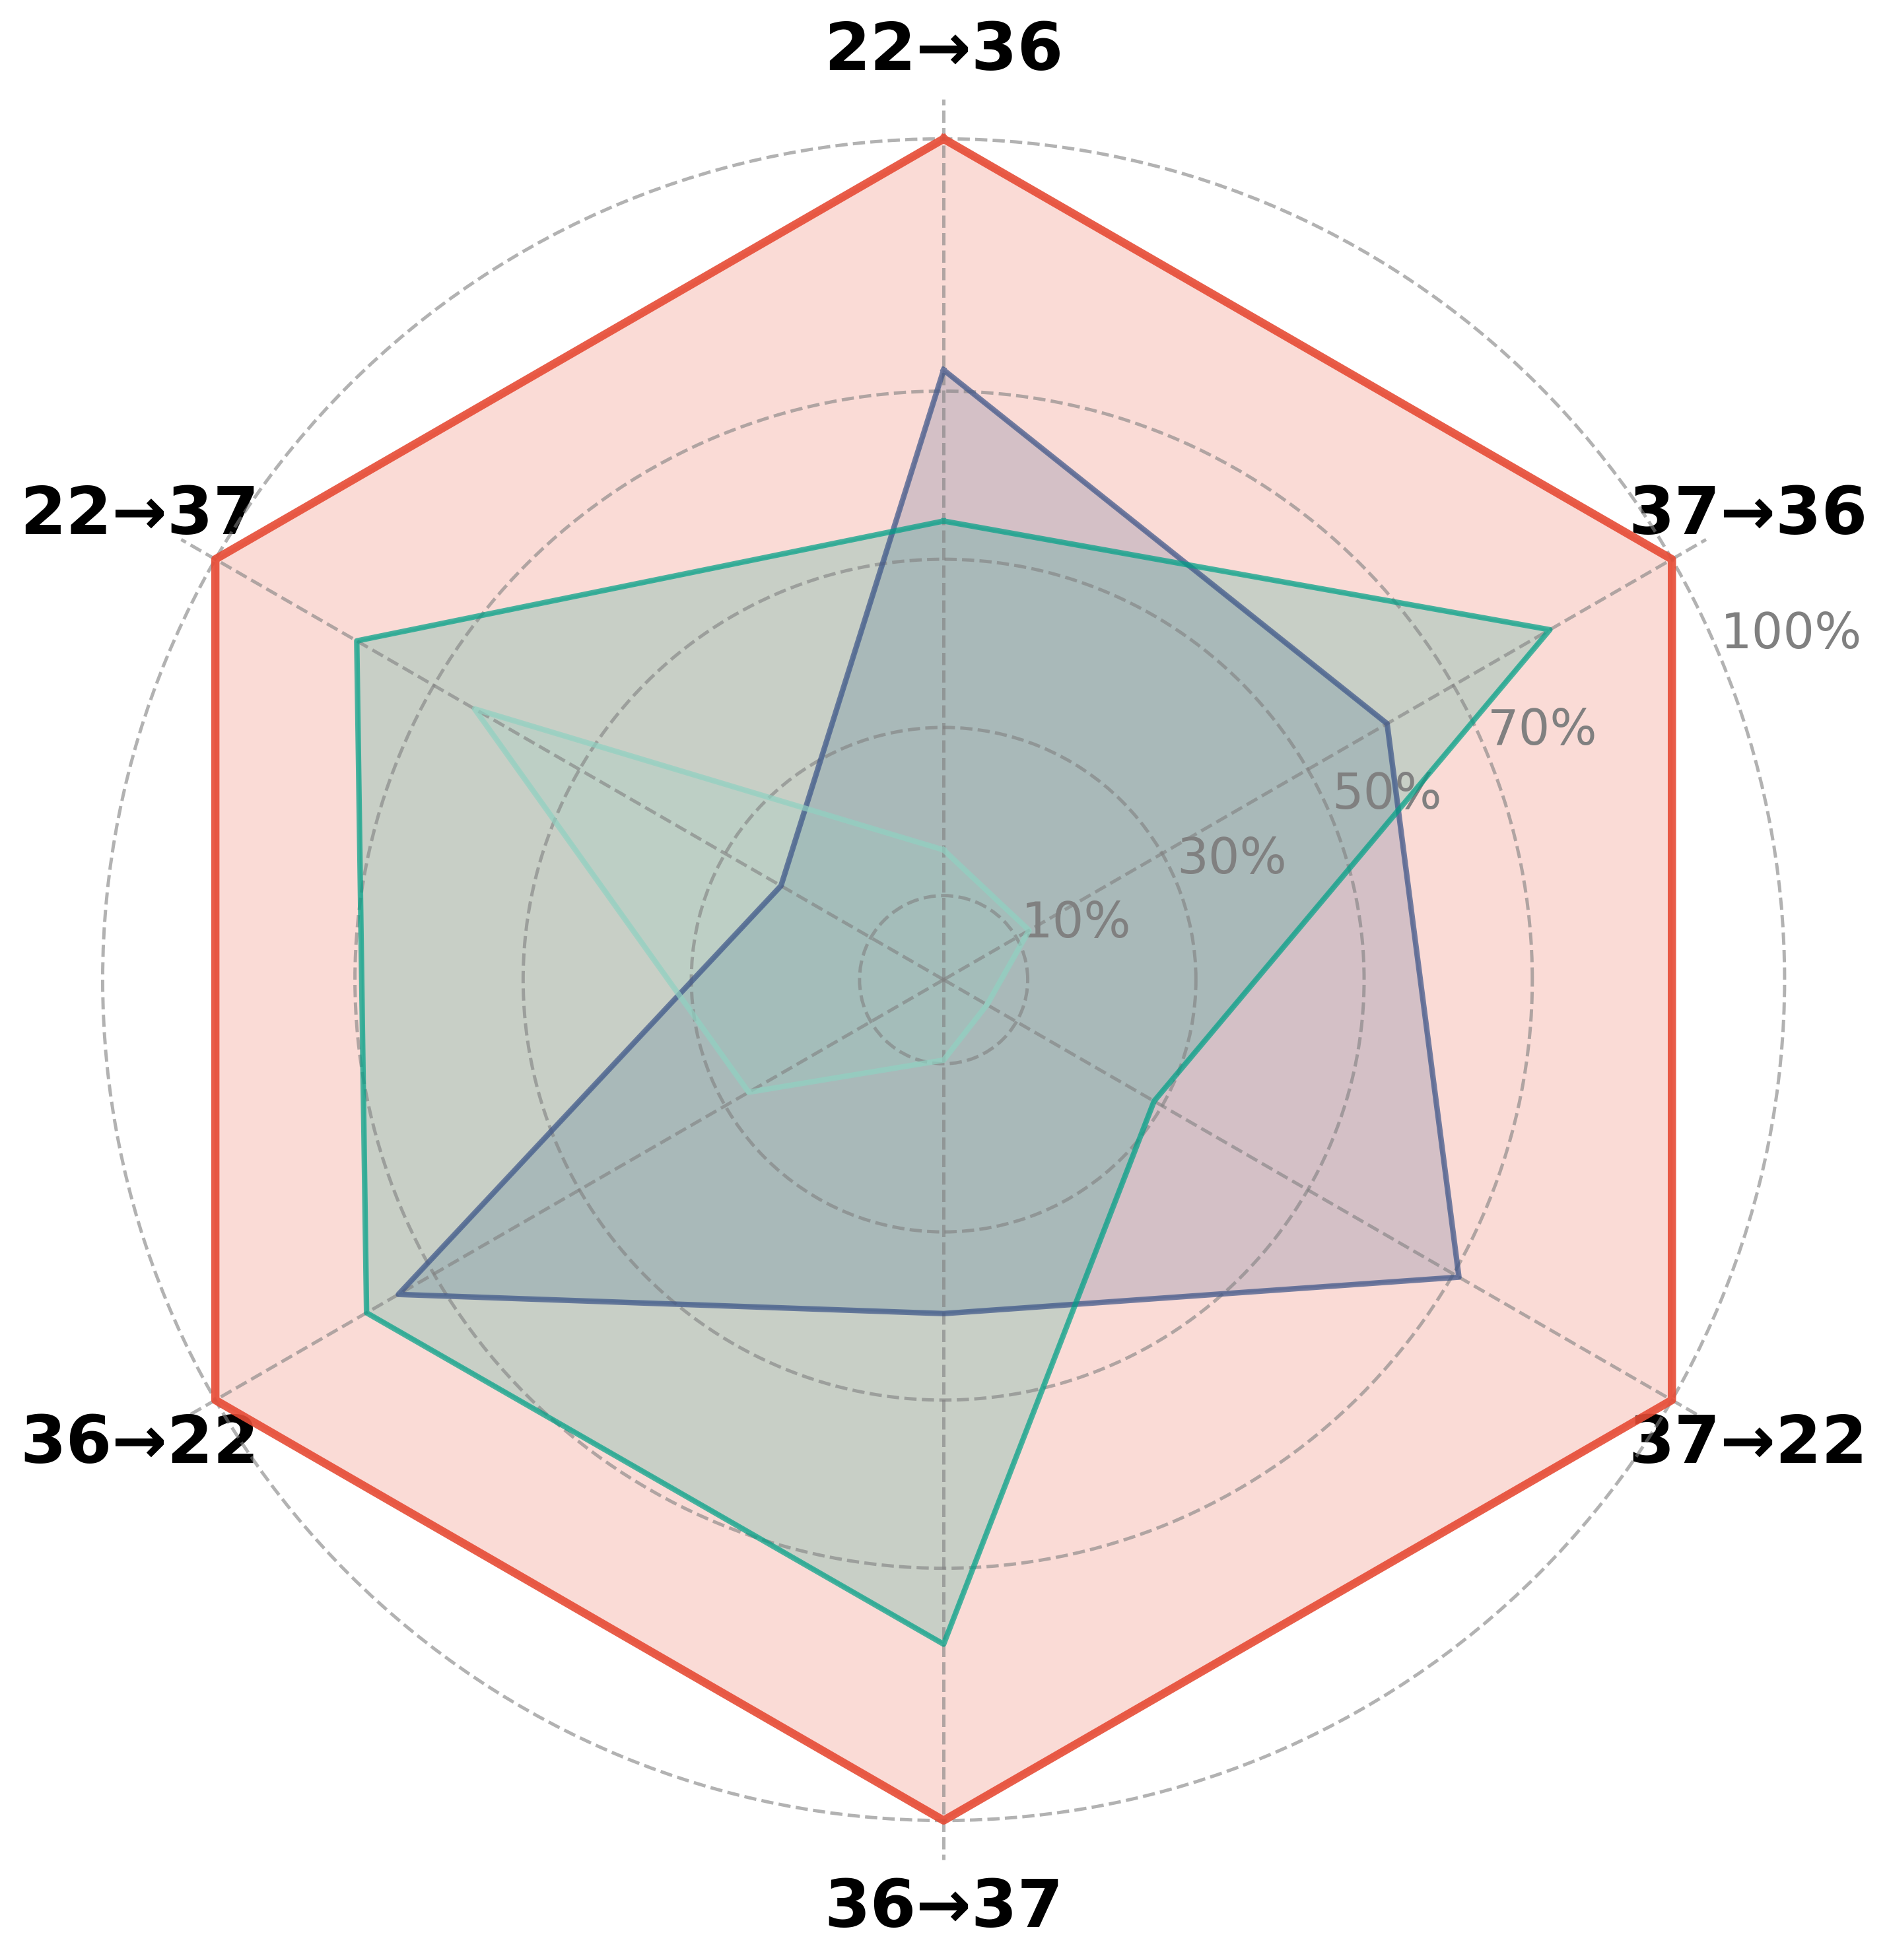

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Data from the table
methods = ['CeMo', 'DeepProfiler', 'ResNet50', 'CellProfiler']
categories = ['22\u219236', '22\u219237', '36\u219222', '36\u219237', '37\u219222', '37\u219236']
values = np.array([
    [22.6, 9.3, 31.2, 14.2, 26.8, 18.4],  # CeMo
    [20, 6.9, 28.9, 9.6, 21.7, 14.9],
    [18.3, 8.7, 29.3, 12.6, 14.4, 16.9],
    [14.6, 8.2, 24.5, 7.3, 10.4, 10.5]
])

# Find the maximum value for each category
max_values = values.max(axis=0)

# Normalize the values by the maximum value for each category
normalized_values = values / max_values

# Radar chart setup
num_vars = len(categories)

# Compute angle for each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# Correct the rotation to ensure a vertex points directly upwards
rotation_offset = np.pi / 2  # Rotate by 90 degrees to point a vertex upwards
angles = [(angle + rotation_offset) % (2 * np.pi) for angle in np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()]
angles += angles[:1]  # Complete the loop

# Find the minimum value for each category and adjust the y-axis range
min_values = values.min(axis=0)
adjusted_min_values = min_values * 0.9  # Set minimum value a bit lower for better visibility

# Normalize values based on adjusted min and max values for each category
adjusted_values = (values - adjusted_min_values) / (max_values - adjusted_min_values)

# Using a different color palette inspired by high-end scientific publications
nature_science_palette = ['#E64B35B2', '#3C5488B2', '#00A087B2', '#91D1C2B2']

# Radar chart setup with Nature/Science-inspired color palette
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True), dpi=300)

# Set the face color of the plot to be a darker grey with more noticeable transparency
ax.set_facecolor((0.8, 0.8, 0.8, 0.4))  # Darker grey with higher transparency

ax.set_facecolor('white')
# Customize the plot background and gridlines
ax.grid(color='grey', linestyle='--', linewidth=1.2, alpha=0.6)

# Customizing gridlines and ticks for a more refined look
ax.spines['polar'].set_visible(False)  # Hide the polar spine to modernize the look
ax.tick_params(colors='grey', size=7, width=1.2)  # Tick styles

# Plot radar chart for each method with Nature/Science-inspired colors
for i, method in enumerate(methods):
    data = adjusted_values[i].tolist()
    data += data[:1]  # Complete the loop
    if method == 'CeMo':
        ax.plot(angles, data, linewidth=3, linestyle='solid', color=nature_science_palette[i], label=method, alpha=0.9)
    else:
        ax.plot(angles, data, linewidth=2, linestyle='solid', color=nature_science_palette[i], label=method, alpha=0.7)
    ax.fill(angles, data, color=nature_science_palette[i], alpha=0.2)

# Adjust y-axis ticks for better visibility
ax.set_yticks([0.1, 0.3, 0.5, 0.7, 1.0])
ax.set_yticklabels(['10%', '30%', '50%', '70%', '100%'], fontsize=18, color='grey')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=24, color='black', fontweight='bold')  # Set task labels to black and bold

# Add a more elegant legend with larger fonts and lighter background 
# legend = plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=28, frameon=True, framealpha=0.8)
# for text in legend.get_texts():
#     text.set_color(nature_science_palette[methods.index(text.get_text())]) # Set legend text color to match line color

# Remove the default title to keep the chart clean
plt.title("", fontsize=22)

# Show plot
plt.tight_layout()
# plt.savefig('./3c_1.pdf', bbox_inches='tight', dpi=300)  
plt.show()


# 十条边

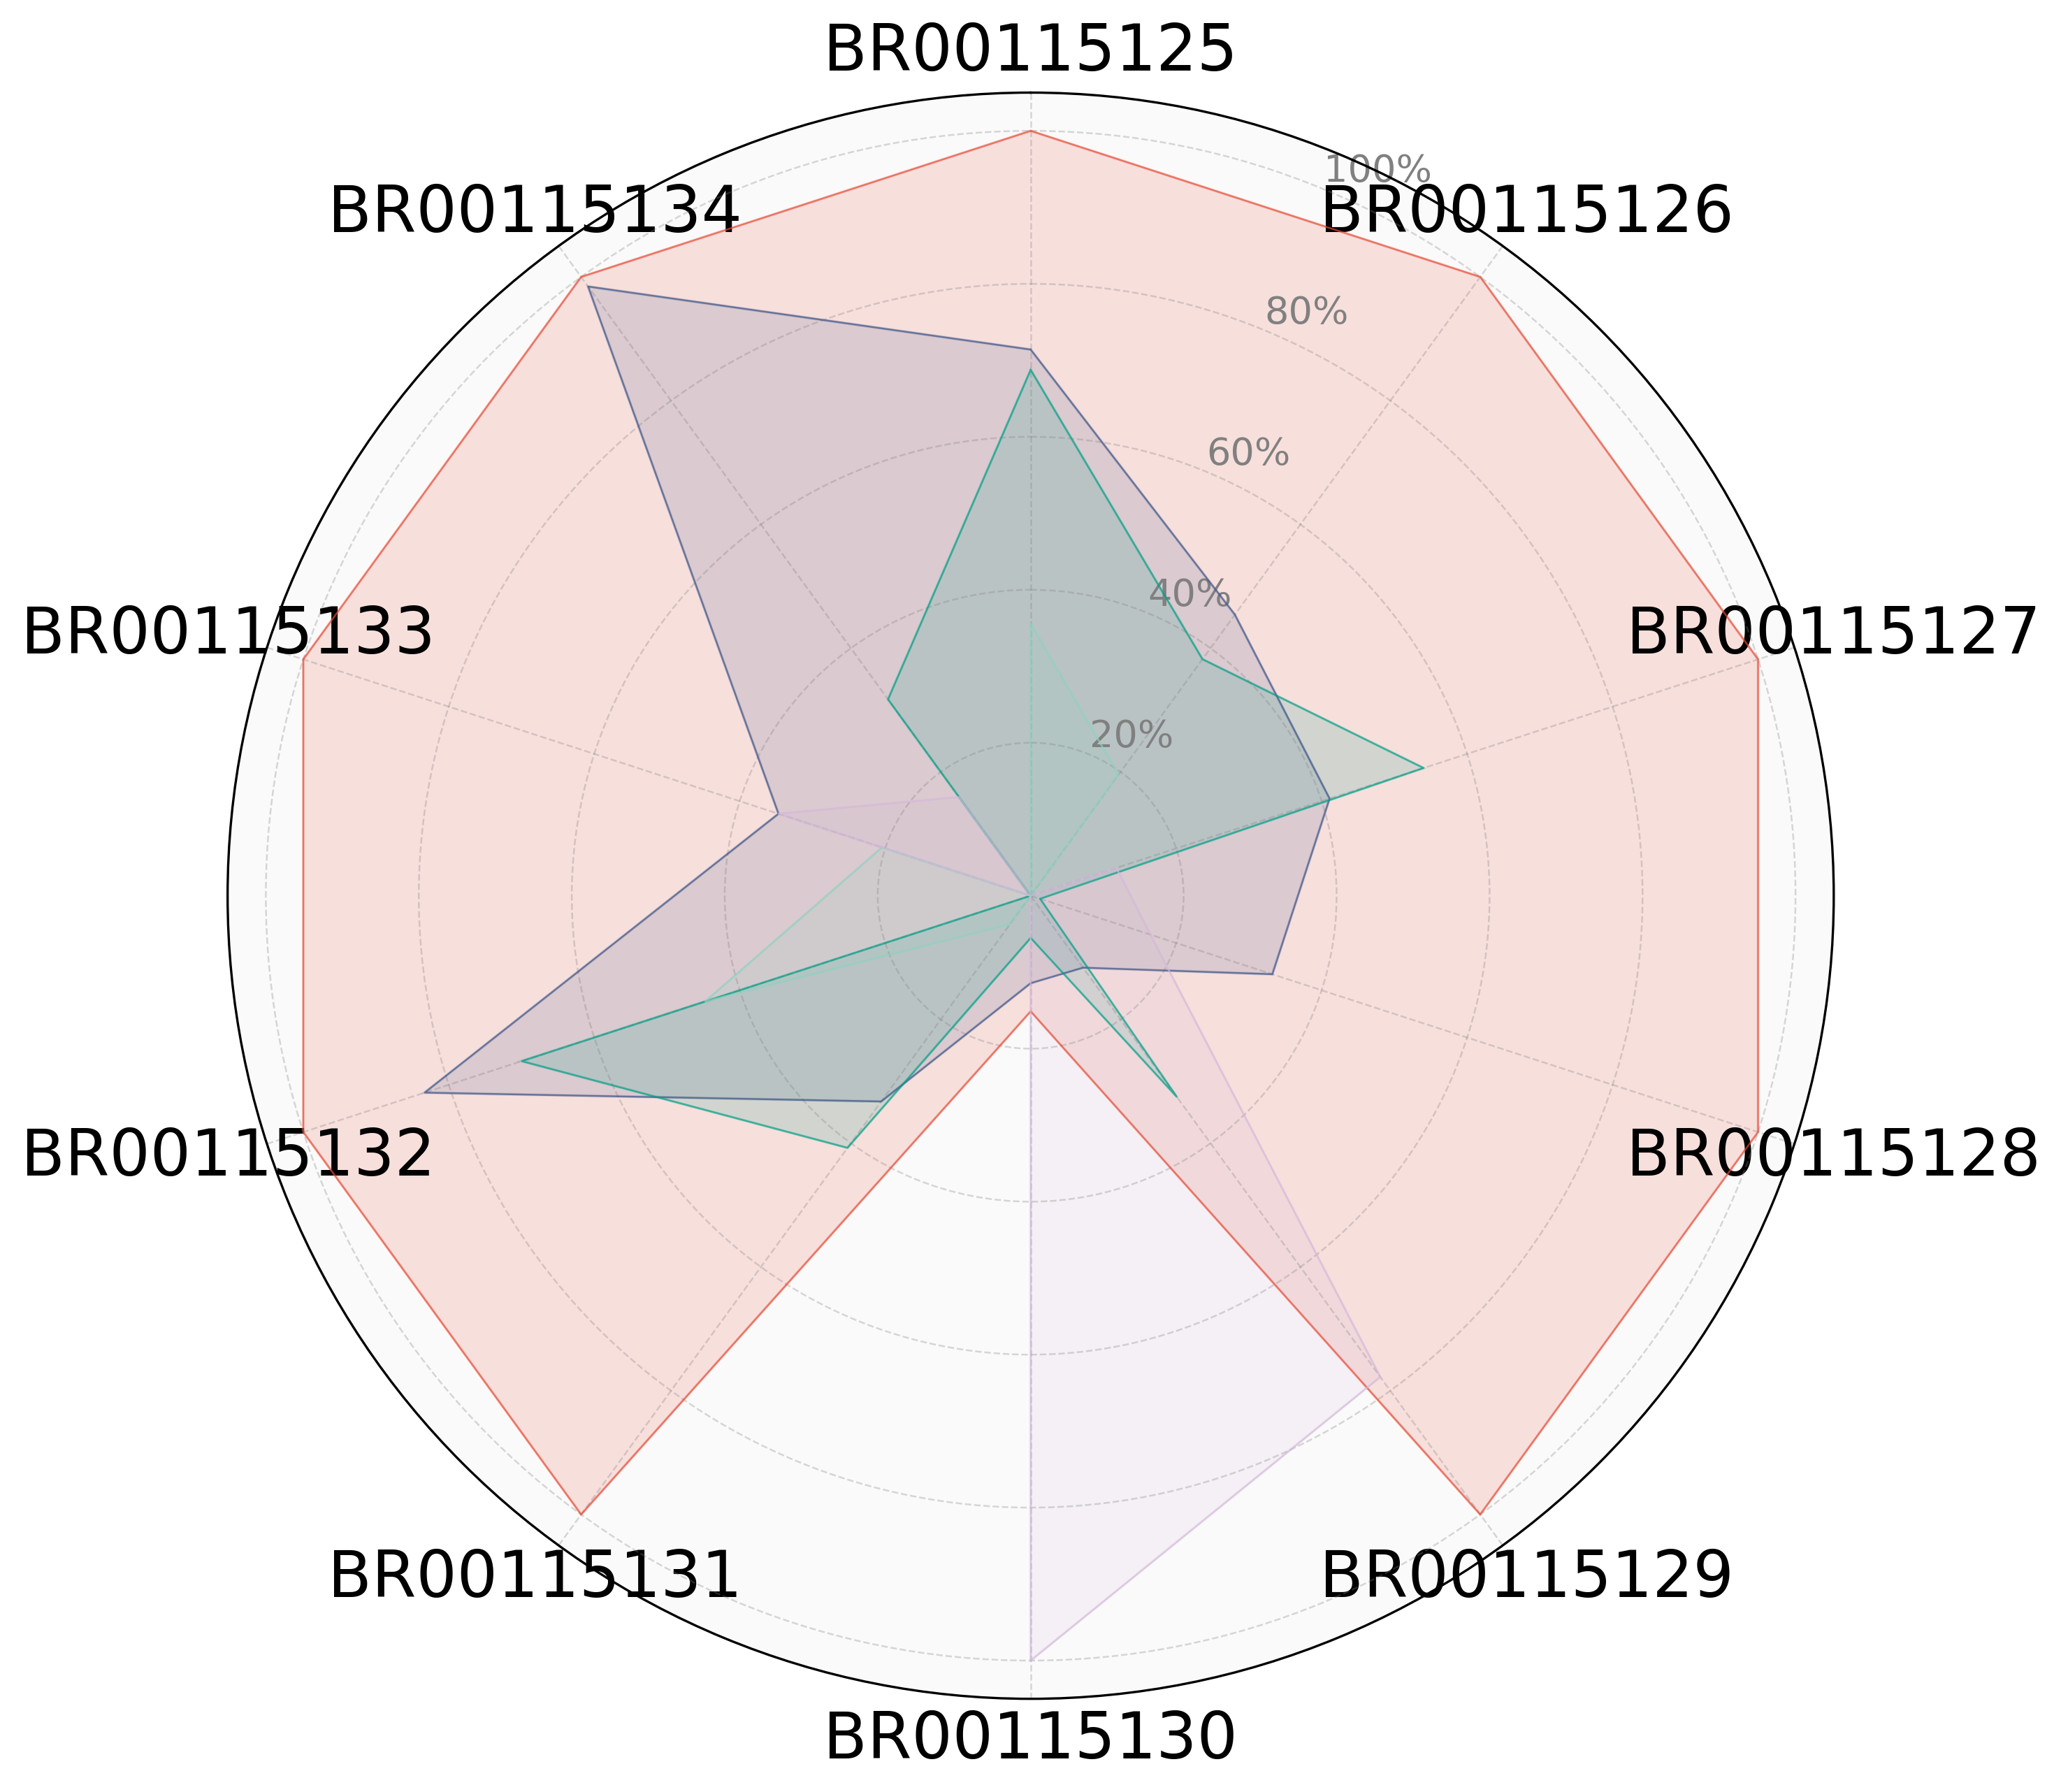

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# 全局字体设置（与3b代码一致）
plt.rcParams['font.size'] = 14  # 字体大小
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 14

# 方法名称
methods = ['PhenoProfiler', 'DeepProfiler', 'ResNet50', 'ViT', 'OpenPhenom']

# 数据集名称
datasets = [f"BR001151{i+25}" for i in range(10)]

# 每种方法在每个数据集上的性能
performance = np.array([
    [10.23, 12.27, 7.16, 11.26, 7.162, 1.323, 6.139, 7.1627, 5.116, 6.149],
    [8.18, 6.13, 5.11, 7.16, 3.06, 1.203, 4.09, 6.139, 4.093, 6.13],
    [7.99, 5.32, 5.56, 5.2, 4.03, 1.01, 4.32, 5.32, 3.55, 5.31],
    [5.61, 3.22, 3.68, 5.12, 2.52, 0.83, 3.21, 3.77, 3.87, 4.92],
    [3.06, 1.02, 4.09, 6.13, 6.13, 4.09, 3.069, 1.0232, 4.093, 5.116]
])

# 找到每个数据集的最大值和最小值
max_values = performance.max(axis=0)
min_values = performance.min(axis=0)

# 归一化数据
normalized_performance = (performance - min_values) / (max_values - min_values)

# 计算角度
angles = np.linspace(0, 2 * pi, len(datasets), endpoint=False).tolist()
angles += angles[:1]  # 闭合图形

# 使用与3b代码类似的高级配色方案
nature_science_palette = ['#E64B35B2', '#3C5488B2', '#00A087B2', '#91D1C2B2', '#D4B9DA']

# 雷达图设置
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True), dpi=300)

# 设置背景颜色和网格线
# ax.set_facecolor((0.8, 0.8, 0.8, 0.4))  # 深灰色背景
ax.set_facecolor((0.9, 0.9, 0.9, 0.2))  # 更浅的灰色，更低透明度
ax.grid(color='grey', linestyle='--', linewidth=0.6, alpha=0.3)

# 绘制雷达图
for i, method in enumerate(methods):
    values = normalized_performance[i].tolist()
    values += values[:1]  # 闭合图形
    ax.plot(angles, values, linewidth=0.6, linestyle='solid', color=nature_science_palette[i], label=method, alpha=0.7)
    ax.fill(angles, values, color=nature_science_palette[i], alpha=0.15)

# 设置角度和标签
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(datasets, fontsize=22, color='black')  # 数据集标签为黑色加粗

# 设置Y轴标签
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], fontsize=13, color='grey')

# 添加图例
# legend = ax.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1), fontsize=18, frameon=True, framealpha=0.8)
# for text in legend.get_texts():
#     text.set_color(nature_science_palette[methods.index(text.get_text())])  # 图例颜色与线条颜色一致
    
# 保存和显示图形
plt.tight_layout()
# plt.savefig('./3c_FoE.pdf', bbox_inches='tight', dpi=300)
plt.show()

# 做参数分析消融试验-适合数值较多的情况

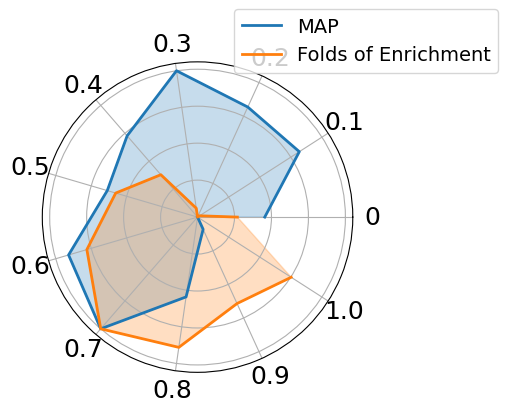

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
loss = ['0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1.0']
map_values = [0.0928, 0.0932, 0.0932, 0.0934, 0.0931, 0.0930, 0.0933, 0.0934, 0.0929, 0.0924, 0.0923]
folds_of_enrichment = [50.14, 49.22, 49.16, 49.38, 50.54, 51.26, 52.0, 52.8, 52.4, 51.5, 51.9]

# 将数据标准化到0-1范围内
map_values = np.array(map_values)
folds_of_enrichment = np.array(folds_of_enrichment)
map_values = (map_values - min(map_values)) / (max(map_values) - min(map_values))
folds_of_enrichment = (folds_of_enrichment - min(folds_of_enrichment)) / (max(folds_of_enrichment) - min(folds_of_enrichment))

# 创建雷达图
labels = np.array(loss)
num_vars = len(labels)

# 计算角度
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# 完成雷达图
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.fill(angles, map_values, color='#1f77b4', alpha=0.25)  # 蓝色
ax.fill(angles, folds_of_enrichment, color='#ff7f0e', alpha=0.25)  # 橙色
ax.plot(angles, map_values, color='#1f77b4', linewidth=2, label='MAP')  # 蓝色
ax.plot(angles, folds_of_enrichment, color='#ff7f0e', linewidth=2, label='Folds of Enrichment')  # 橙色

# 添加标签
ax.set_yticklabels([])
ax.set_xticks(angles)
ax.set_xticklabels(labels, fontsize=18)

# # 添加图例
ax.legend(loc='upper right', bbox_to_anchor=(1.5, 1.2))

fig.tight_layout()
# 保存高分辨率图像
# plt.savefig('3c_22.pdf', dpi=300)
# 显示图表
plt.show()